In [2]:
from matplotlib import pyplot as plt
import os
import json
from tqdm import tqdm

In [12]:
def get_all_filepaths(directory):
    filepaths = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepaths.append(file)
    return filepaths

In [13]:
dir_path = "./training_runs"
training_files = get_all_filepaths(dir_path)

training_stats = {}
for file in training_files:
    with open(os.path.join(dir_path, file)) as f:
        stats = json.load(f)
    training_stats[file.split('_training_stats')[0]] = stats

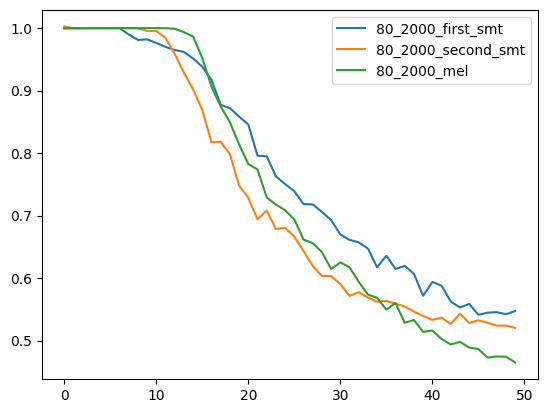

In [38]:
for key in training_stats.keys():
    params = key.split("_")
    if "80" == params[0] and "2000" == params[1]:
        plt.plot(training_stats[key]['val_CER'], label=key)
plt.legend()
plt.show()


In [3]:
import torch
from ctc import *
from smtlstm import *
import numpy as np
from smt_accumulator import *
from SMT import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def solve_SMT_matrix(smt_stats: SMTStats):
    V = smt_stats.V
    M = smt_stats.M
    # ------------------------------------------------------------
    # Solve generalized eigenproblem M u = λ V u
    # via Cholesky reduction
    # ------------------------------------------------------------
    L = torch.linalg.cholesky(V)

    # C = L^{-1} M L^{-T}
    Linv_M = torch.linalg.solve_triangular(L, M, upper=False, left=True)
    C = torch.linalg.solve_triangular(
        L, Linv_M.transpose(-1, -2), upper=False, left=True
    ).transpose(-1, -2)

    # Symmetrize for numerical stability
    C = 0.5 * (C + C.T)

    eigvals, y = torch.linalg.eigh(C)

    # Recover generalized eigenvectors
    eigvecs = torch.linalg.solve_triangular(L.T, y, upper=True, left=True)
    return eigvals, eigvecs

In [5]:
import re
from g2p_en import G2p

def make_dataloader(dataset, tokenizer, batch_size=16, shuffle=True, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=lambda batch: ctc_collate_fn(batch, tokenizer),
    )

class NormBetaDataset(Dataset):
    """Simple utterance-level dataset built from norm_beta and utterance bounds."""
    def __init__(self, norm_beta: np.ndarray, utterance_bounds, texts=None, phonemes: bool = False):
        self.norm_beta = norm_beta
        self.utterance_bounds = list(utterance_bounds)
        self.g2p = G2p()
        self.phonemes = phonemes
        if texts is None:
            self.texts = [""] * len(self.utterance_bounds)
        else:
            if len(texts) != len(self.utterance_bounds):
                raise ValueError("texts must match utterance_bounds length")
            self.texts = list(texts)

    def __len__(self):
        return len(self.utterance_bounds)

    def __getitem__(self, idx):
        start, end = self.utterance_bounds[idx]
        x = torch.as_tensor(self.norm_beta[start:end, :], dtype=torch.float32)
        targets = self._text_to_phonemes(self.texts[idx]) if self.phonemes else self.texts[idx]
        return {
            "features": x,
            "text": targets,
        }
    
    def _text_to_phonemes(self, text, remove_stress=True):
        phonemes = self.g2p(text)

        # remove spaces/punctuation tokens
        phonemes = [p for p in phonemes if p.strip()]

        if remove_stress:
            phonemes = [p.rstrip("012") for p in phonemes]

        return phonemes

In [ ]:
patch_sizes = ['_50']
diff_orders = ['second']
data_sizes = [8000]
dir = "/mnt/data/SMT/"
for patch_size in patch_sizes:
    patch_size_int = int(patch_size.split("_")[1])
    patch_dir = os.path.join(dir, patch_size)
    norm_patches = np.load(os.path.join(patch_dir, "norm_patches.npy"))
    utterance_bounds = np.load(os.path.join(patch_dir, "utterance_bounds.npy"))
    text = np.load(os.path.join(patch_dir, "text.npy"))
    for diff_order in diff_orders:

        smt_stats = torch.load(os.path.join(patch_dir, f"{diff_order}/smt_stats.pt"), weights_only=False)
        sparse_codes = torch.load(os.path.join(patch_dir, f"{diff_order}/sparse_codes.pt"))

        eigvals, eigvecs = solve_SMT_matrix(smt_stats)
        d = (int(patch_size_int/5)*20)
        P = eigvecs[:, 1:d+1].T

        beta = P.cpu()@sparse_codes.T
        norm_beta, _, _, _ = preprocess_patches(beta.T.cpu().numpy()) # this switches beta to be NxD like norm_patches
        norm_beta = norm_beta

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        tokenizer = CharTokenizer()
        for data_size in data_sizes:
            # train log mel model on norm patches
            train_split =int(data_size*0.85)
            val_split = int(data_size*0.15)
            print(utterance_bounds.shape)
            train_bounds = utterance_bounds[:train_split]
            train_text = text[:train_split]

            # ensure we are always using same validation set for better comparisons
            val_bounds = utterance_bounds[-val_split:]
            val_text = text[-val_split:]

            train_dataset = NormBetaDataset(norm_beta, train_bounds, train_text, phonemes=False)
            val_dataset = NormBetaDataset(norm_beta, val_bounds, val_text, phonemes=False)

            tokenizer = CharTokenizer()
            train_loader = make_dataloader(train_dataset, tokenizer, batch_size=100, shuffle=True)
            val_loader = make_dataloader(val_dataset, tokenizer, batch_size=100, shuffle=False)

            # Infer input dimension from one sample
            sample = train_dataset[0]["features"]
            d_in = sample.shape[1]

            model = load_trained_bilstm_model(
                checkpoint_path=os.path.join(patch_dir, f"smt_{patch_size}_{data_size}_{diff_order}_ctc.pt"),
                d_in=d_in,
                hidden_size = 256,
                vocab_size=tokenizer.vocab_size,
                device=device,
            )

            val_results = []
            for sample in tqdm(val_dataset):
                pred = predict_one(
                    model=model,
                    features=sample["features"],
                    tokenizer=tokenizer,
                    device=device,
                    decode_method="beam",
                    beam_width=20,
                    return_confidence=True,
                )

                val_results.append({"Reference": sample["text"],
                                    "Predicted": pred["text"],
                                    "Confidence": pred["confidence"]})
            with open(os.path.join(patch_dir, f"smt_{patch_size}_{data_size}_{diff_order}_val_results.json"), 'w') as f:
                json.dump(val_results, f, indent=4)
            

normalize patches
zca patches
(2000, 2)


 73%|███████▎  | 879/1200 [1:21:11<24:59,  4.67s/it]  